In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
df = pd.read_csv('data/train.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (9800, 18)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# Parse date
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Sort by date
df = df.sort_values('Order Date').reset_index(drop=True)

# Check missing values
print("Missing values:\n", df.isnull().sum())
df.dropna(inplace=True)

# Group by date
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales.columns = ['date', 'total_sales']

print("\n✅ Data cleaned!")
print(daily_sales.head())

Missing values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

✅ Data cleaned!
        date  total_sales
0 2015-01-03       16.448
1 2015-01-04      288.060
2 2015-01-05       19.536
3 2015-01-06     4407.100
4 2015-01-07       87.158


In [4]:
daily_sales['year']        = daily_sales['date'].dt.year
daily_sales['month']       = daily_sales['date'].dt.month
daily_sales['day']         = daily_sales['date'].dt.day
daily_sales['dayofweek']   = daily_sales['date'].dt.dayofweek
daily_sales['quarter']     = daily_sales['date'].dt.quarter
daily_sales['weekofyear']  = daily_sales['date'].dt.isocalendar().week.astype(int)
daily_sales['is_weekend']  = daily_sales['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

# Lag features
daily_sales['lag_1']  = daily_sales['total_sales'].shift(1)
daily_sales['lag_7']  = daily_sales['total_sales'].shift(7)
daily_sales['lag_30'] = daily_sales['total_sales'].shift(30)

# Rolling mean
daily_sales['rolling_mean_7']  = daily_sales['total_sales'].rolling(window=7).mean()
daily_sales['rolling_mean_30'] = daily_sales['total_sales'].rolling(window=30).mean()

# Drop NaN rows created by lag/rolling
daily_sales.dropna(inplace=True)

print("✅ Features engineered!")
print(daily_sales.shape)
daily_sales.head()

✅ Features engineered!
(1199, 14)


,date,total_sales,year,month,day,dayofweek,quarter,weekofyear,is_weekend,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
30,2015-02-14,576.726,2015,2,14,5,1,7,1,129.568,97.112,16.448,487.067143,612.546233
31,2015-02-15,21.360,2015,2,15,6,1,7,1,576.726,134.384,288.060,470.920857,603.656233
32,2015-02-16,9.040,2015,2,16,0,1,8,0,21.360,330.512,19.536,424.996286,603.306367
33,2015-02-17,54.208,2015,2,17,1,1,8,0,9.040,180.320,4407.100,406.980286,458.209967
34,2015-02-18,37.784,2015,2,18,2,1,8,0,54.208,14.560,87.158,410.298000,456.564167


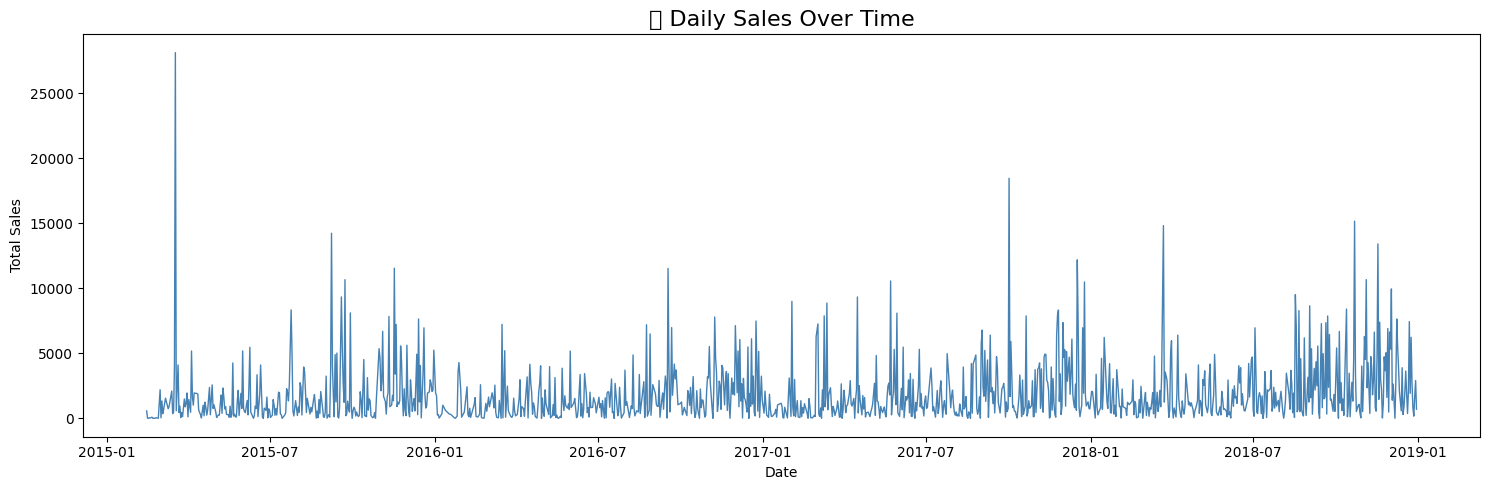

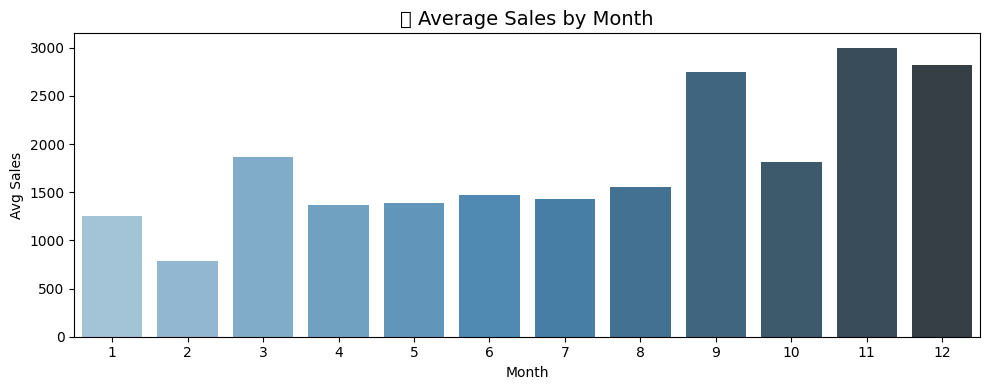

In [5]:
plt.figure(figsize=(15, 5))
plt.plot(daily_sales['date'], daily_sales['total_sales'], color='steelblue', linewidth=1)
plt.title('📈 Daily Sales Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('sales_trend.png', dpi=150)
plt.show()

# Monthly average
monthly = daily_sales.groupby('month')['total_sales'].mean()
plt.figure(figsize=(10, 4))
sns.barplot(x=monthly.index, y=monthly.values, palette='Blues_d')
plt.title('📊 Average Sales by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Avg Sales')
plt.tight_layout()
plt.savefig('monthly_avg.png', dpi=150)
plt.show()

In [6]:
features = ['year', 'month', 'day', 'dayofweek', 'quarter',
            'weekofyear', 'is_weekend', 'lag_1', 'lag_7',
            'lag_30', 'rolling_mean_7', 'rolling_mean_30']

X = daily_sales[features]
y = daily_sales['total_sales']

# Time-based split (no shuffle for time series!)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("✅ Models trained!")

Train size: 959 | Test size: 240
✅ Models trained!


In [7]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"\n📌 {name}")
    print(f"   MAE  : {mae:.2f}")
    print(f"   RMSE : {rmse:.2f}")
    print(f"   MAPE : {mape:.2f}%")

evaluate("Linear Regression", y_test, lr_preds)
evaluate("Random Forest",     y_test, rf_preds)


📌 Linear Regression
   MAE  : 1607.79
   RMSE : 2182.81
   MAPE : 648.56%

📌 Random Forest
   MAE  : 1734.36
   RMSE : 2339.22
   MAPE : 720.56%


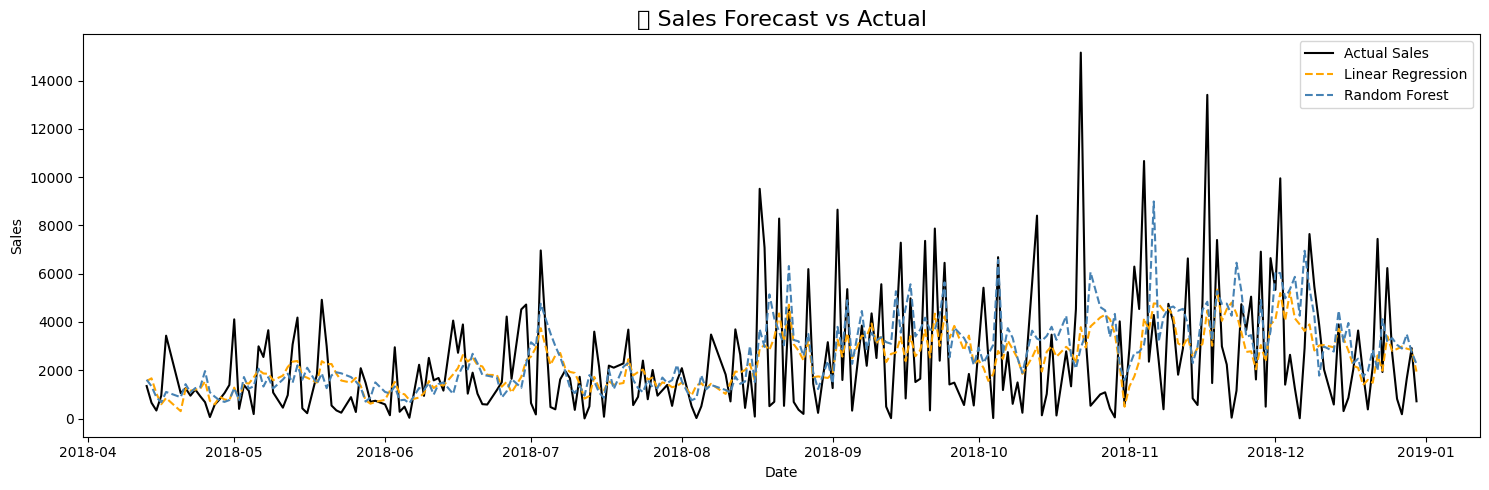

✅ Forecast chart saved!


In [8]:
test_dates = daily_sales['date'].iloc[split:].values

plt.figure(figsize=(15, 5))
plt.plot(test_dates, y_test.values,  label='Actual Sales',      color='black',      linewidth=1.5)
plt.plot(test_dates, lr_preds,       label='Linear Regression', color='orange',     linestyle='--')
plt.plot(test_dates, rf_preds,       label='Random Forest',     color='steelblue',  linestyle='--')
plt.title('🔮 Sales Forecast vs Actual', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.savefig('forecast_output.png', dpi=150)
plt.show()
print("✅ Forecast chart saved!")

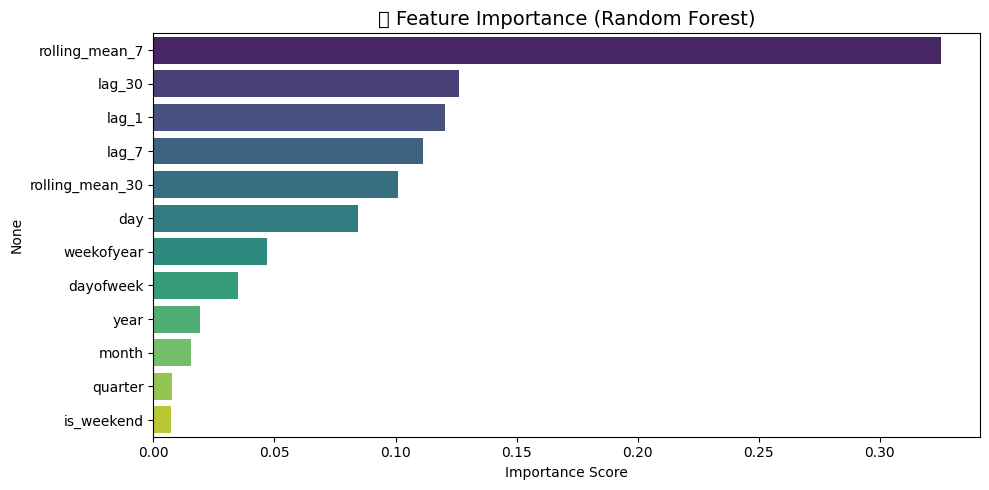

In [9]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('🔑 Feature Importance (Random Forest)', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [ ]:
print("=" * 50)
print("📊 BUSINESS FORECAST SUMMARY")
print("=" * 50)
print(f"Total records analysed : {len(daily_sales)}")
print(f"Date range             : {daily_sales['date'].min().date()} → {daily_sales['date'].max().date()}")
print(f"Avg Daily Sales        : {daily_sales['total_sales'].mean():.2f}")
print(f"Peak Sales Day         : {daily_sales.loc[daily_sales['total_sales'].idxmax(), 'date'].date()}")
print(f"Best Model             : Random Forest")
print(f"Random Forest RMSE     : {np.sqrt(mean_squared_error(y_test, rf_preds)):.2f}")
print("=" * 50)

📊 BUSINESS FORECAST SUMMARY
Total records analysed : 1199
Date range             : 2015-02-14 → 2018-12-30
Avg Daily Sales        : 1863.88
Peak Sales Day         : 2015-03-18
Best Model             : Random Forest
Random Forest RMSE     : 2339.22
✅ Task 1 Complete — Ready for GitHub submission!
